<span style='font-size:40px; display:block;'>
<b>
    NEE ridge plots
</b>
</span>

**Author**: Lukas Hörtnagl (holukas@ethz.ch)

# **Imports**

In [1]:
import importlib.metadata
import warnings
from datetime import datetime
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.cumulative import CumulativeYear
from diive.core.plotting.heatmap_datetime import HeatmapDateTime, HeatmapYearMonth
from diive.core.plotting.xridgeplot import RidgePlotTS

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.86.0


# **Load data**

In [2]:
SOURCEDIR = r"../60_MERGE_DATA_FLUXES"
FILENAME = r"61.1_FLUXES_M10_MGMT_L4.1_NEE_LE_H_FN2O_FCH4.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
df = load_parquet(filepath=FILEPATH)
df

Loaded .parquet file ..\60_MERGE_DATA_FLUXES\61.1_FLUXES_M10_MGMT_L4.1_NEE_LE_H_FN2O_FCH4.parquet (0.593 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-12,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-18,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-24,.PREC_RAIN_TOT_GF1_0.5_1_MEAN3H-6,.SWC_GF1_0.15_1_gfXG_MEAN3H-12,.SWC_GF1_0.15_1_gfXG_MEAN3H-18,.SWC_GF1_0.15_1_gfXG_MEAN3H-24,.SWC_GF1_0.15_1_gfXG_MEAN3H-6,.TS_GF1_0.04_1_gfXG_MEAN3H-12,.TS_GF1_0.04_1_gfXG_MEAN3H-18,.TS_GF1_0.04_1_gfXG_MEAN3H-24,.TS_GF1_0.04_1_gfXG_MEAN3H-6,.TS_GF1_0.15_1_gfXG_MEAN3H-12,.TS_GF1_0.15_1_gfXG_MEAN3H-18,.TS_GF1_0.15_1_gfXG_MEAN3H-24,...,FCH4_L3.1_L3.3_CUT_50_QCF,FCH4_L3.1_L3.3_CUT_50_QCF0,FLAG_L3.3_CUT_84_FCH4_L3.1_USTAR_TEST,SUM_L3.3_CUT_84_FCH4_L3.1_HARDFLAGS,SUM_L3.3_CUT_84_FCH4_L3.1_SOFTFLAGS,SUM_L3.3_CUT_84_FCH4_L3.1_FLAGS,FLAG_L3.3_CUT_84_FCH4_L3.1_QCF,FCH4_L3.1_L3.3_CUT_84_QCF,FCH4_L3.1_L3.3_CUT_84_QCF0,FCH4_L3.1_L3.3_CUT_16_QCF_gfRF,FLAG_FCH4_L3.1_L3.3_CUT_16_QCF_gfRF_ISFILLED,FCH4_L3.1_L3.3_CUT_50_QCF_gfRF,FLAG_FCH4_L3.1_L3.3_CUT_50_QCF_gfRF_ISFILLED,FCH4_L3.1_L3.3_CUT_84_QCF_gfRF,FLAG_FCH4_L3.1_L3.3_CUT_84_QCF_gfRF_ISFILLED
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2005-01-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 21:45:00,0.0,0.0,0.0,0.0,52.229004,52.226300,52.226689,52.216796,3.458828,3.150402,3.115260,3.660897,4.335667,4.347764,4.385967,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-31 22:15:00,0.0,0.0,0.0,0.0,52.227858,52.227986,52.224528,52.214211,3.522570,3.187638,3.103440,3.643396,4.338551,4.342880,4.379524,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-31 22:45:00,0.0,0.0,0.0,0.0,52.226640,52.229837,52.222456,52.209876,3.578745,3.230037,3.095339,3.624025,4.343767,4.339440,4.372636,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **Air temperature**

In [3]:
# [print(c) for c in df.columns if "NEE" in c]

In [4]:
series = df['NEE_L3.1_L3.3_CUT_50_QCF_gfRF'].copy()
series

TIMESTAMP_MIDDLE
2005-01-01 00:15:00    0.929992
2005-01-01 00:45:00    0.928927
2005-01-01 01:15:00    1.664379
2005-01-01 01:45:00    1.639928
2005-01-01 02:15:00    1.658089
                         ...   
2024-12-31 21:45:00    1.124673
2024-12-31 22:15:00    1.073372
2024-12-31 22:45:00    1.046967
2024-12-31 23:15:00    1.372674
2024-12-31 23:45:00    1.061307
Freq: 30min, Name: NEE_L3.1_L3.3_CUT_50_QCF_gfRF, Length: 350640, dtype: float64

In [17]:
var = "NEE"
units = r"$\mathrm{\mu mol\ CO_{2}\ m^{-2}\ s^{-1}}$"
xlabel = f"{var} ({units})"
xlim = [-20, 20]

## All years (2005-2024)

### Per year (2005-2024)

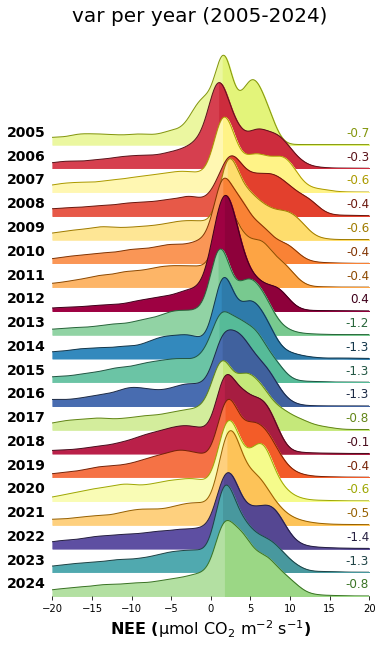

In [14]:
rp = RidgePlotTS(series=series)
rp.per_year(xlim=xlim, ylim=[0, 0.14], hspace=-0.8, xlabel=xlabel,
            fig_width=5, fig_height=9, shade_percentile=0.5, show_mean_line=False,
            fig_title=f"{var} per year (2005-2024)", fig_dpi=72)

### Per month (2005-2024)

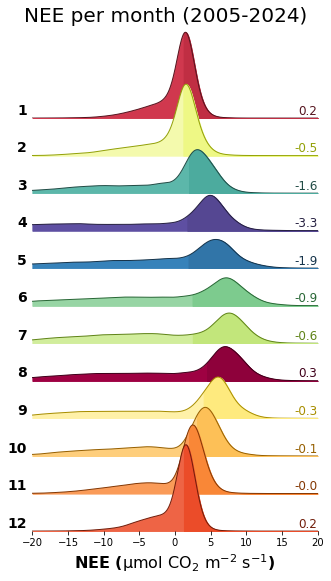

In [20]:
rp.per_month(xlim=xlim, ylim=[0, 0.25], hspace=-0.6, xlabel=xlabel,
             fig_width=4.5, fig_height=8, shade_percentile=0.5, show_mean_line=False,
             fig_title=f"{var} per month (2005-2024)", fig_dpi=72)

### Per week (2005-2024)

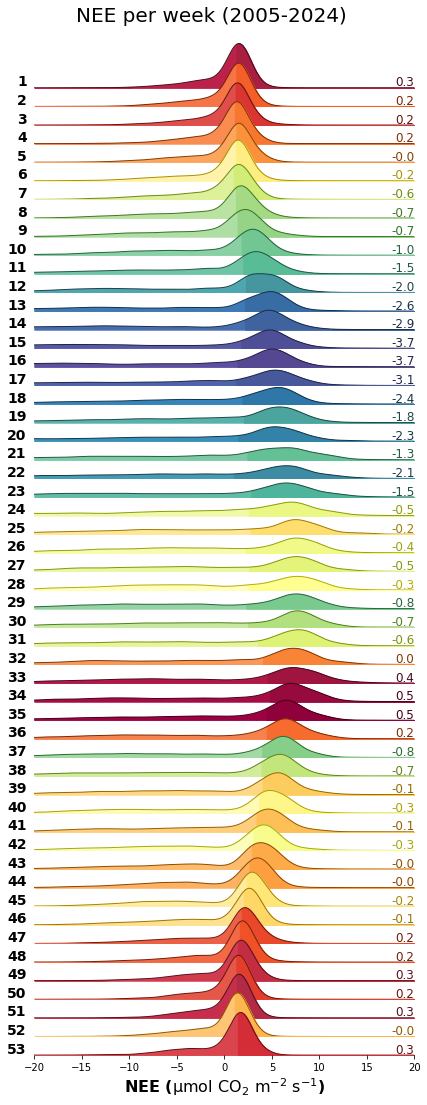

In [21]:
rp.per_week(xlim=xlim, ylim=[0, 0.25], hspace=-0.6, xlabel=xlabel,
            fig_width=6, fig_height=16, shade_percentile=0.5, show_mean_line=False,
            fig_title=f"{var} per week (2005-2024)", fig_dpi=72)

# Single years per month

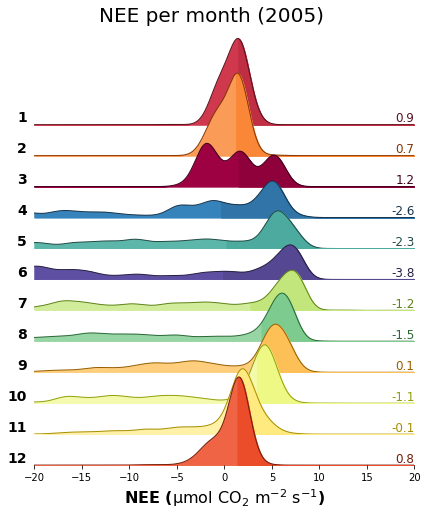

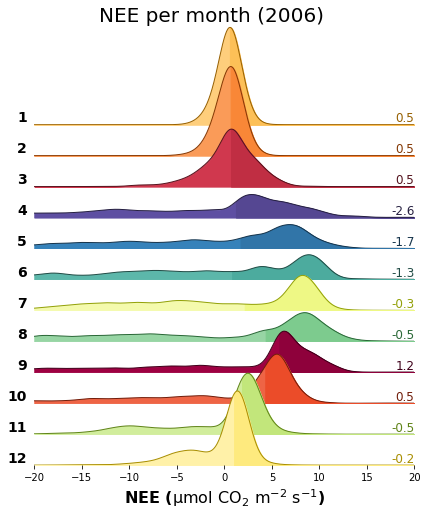

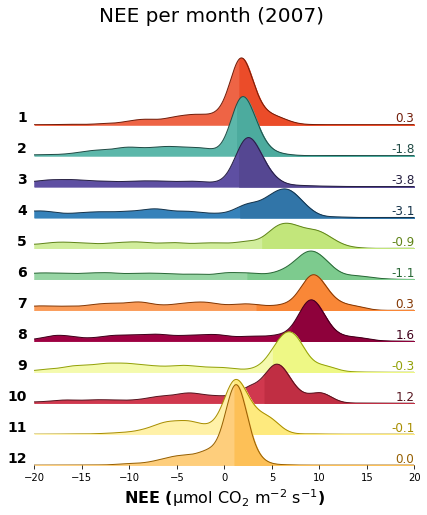

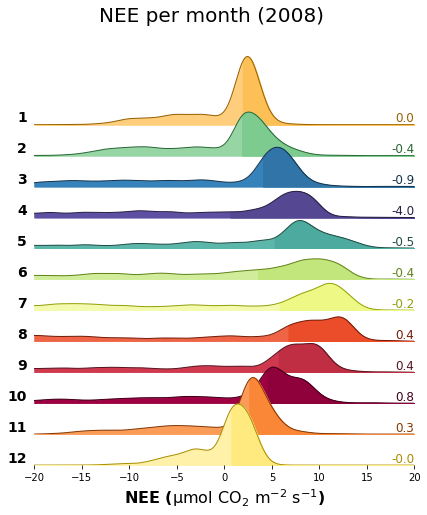

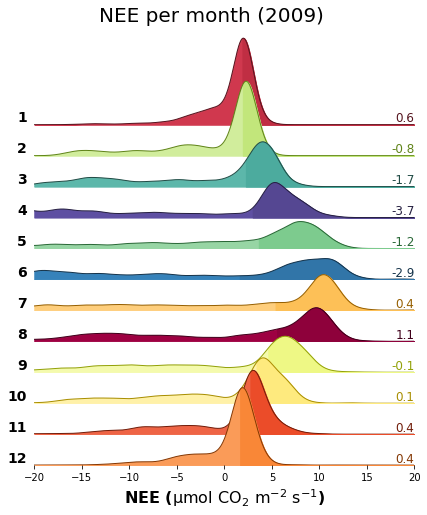

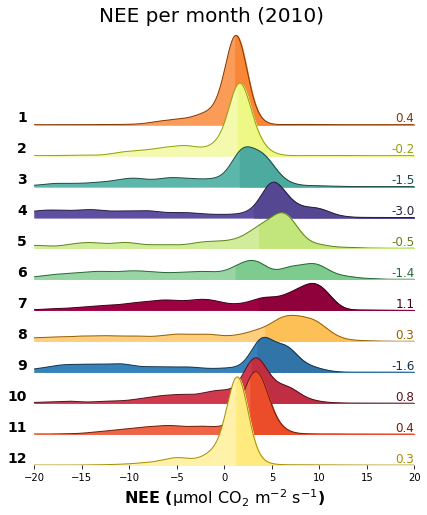

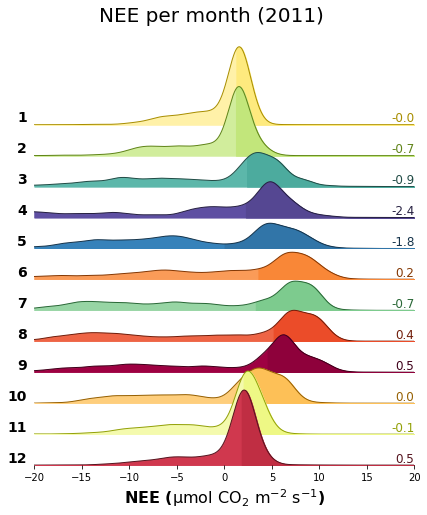

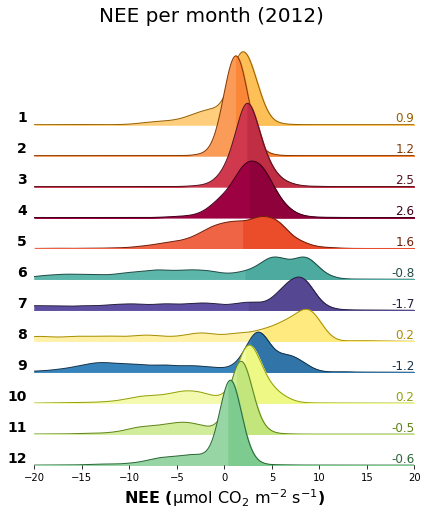

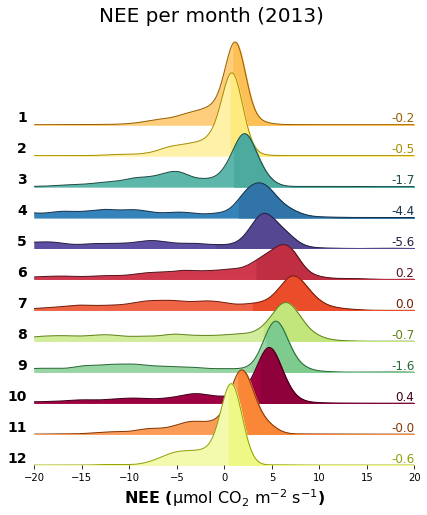

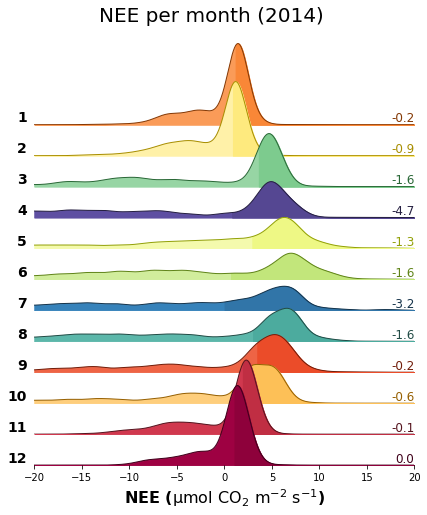

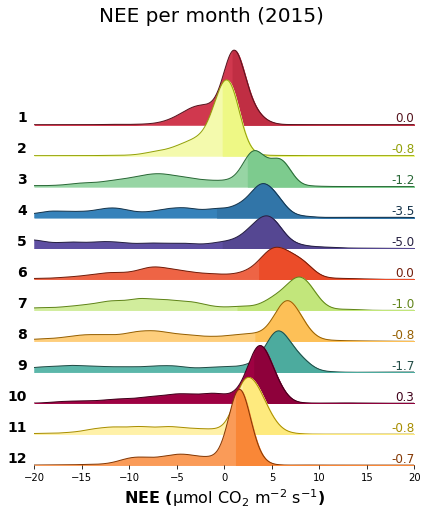

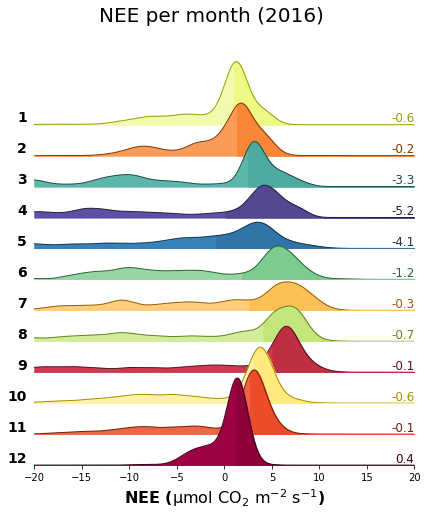

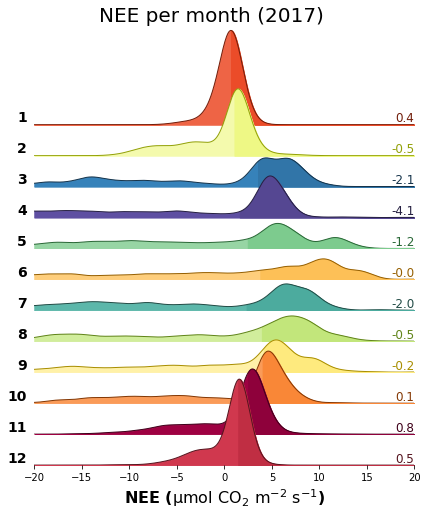

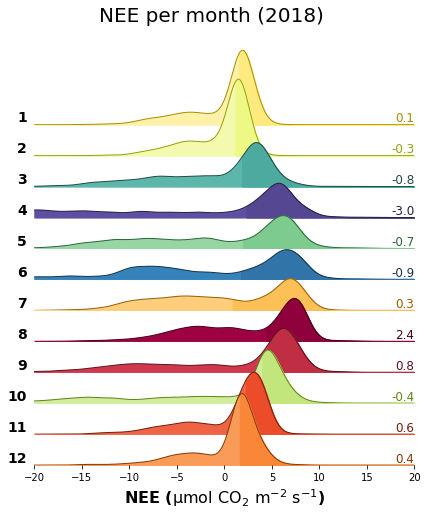

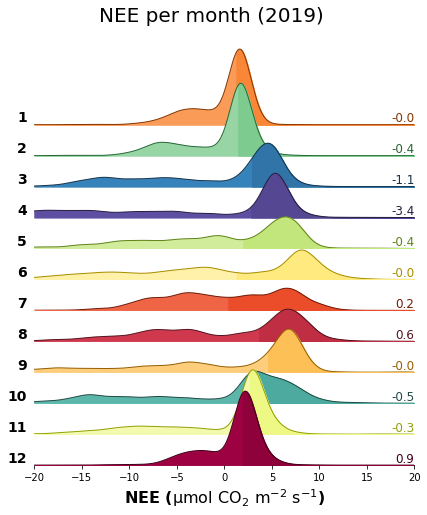

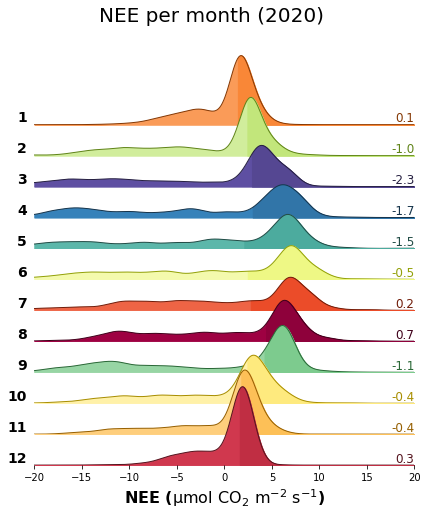

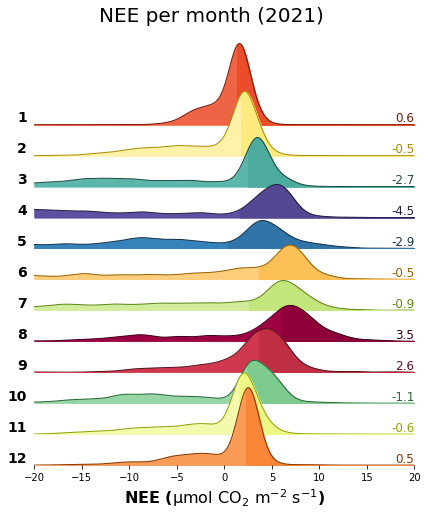

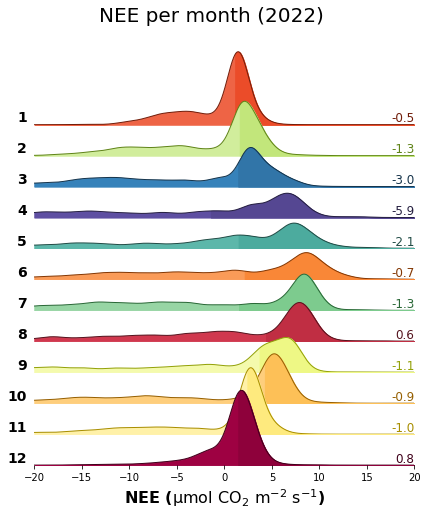

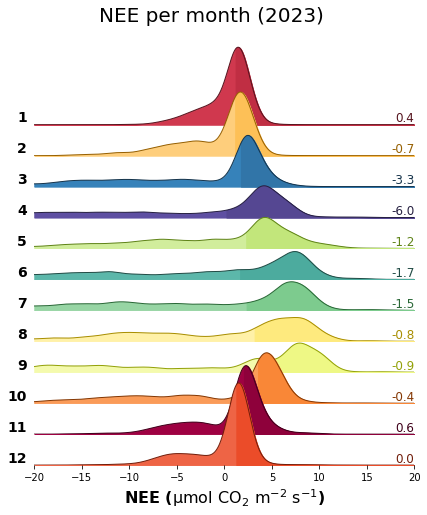

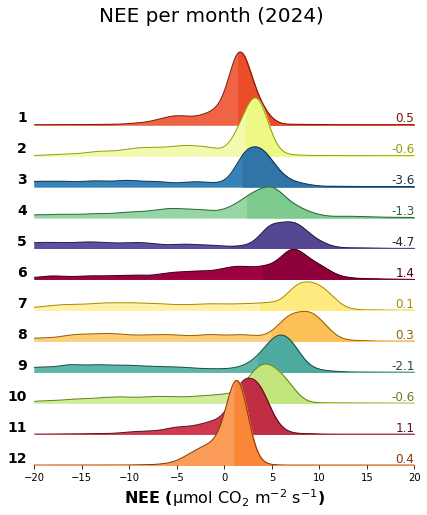

In [25]:
uniq_years = series.index.year.unique()
for uy in uniq_years:
    series_yr = series.loc[series.index.year == uy].copy()
    rp = RidgePlotTS(series=series_yr)
    rp.per_month(xlim=xlim, ylim=[0, 0.32], hspace=-0.7, xlabel=xlabel,
                 fig_width=6, fig_height=7, shade_percentile=0.5, show_mean_line=False,
                 fig_title=f"{var} per month ({uy})", fig_dpi=72)

# Single years per week

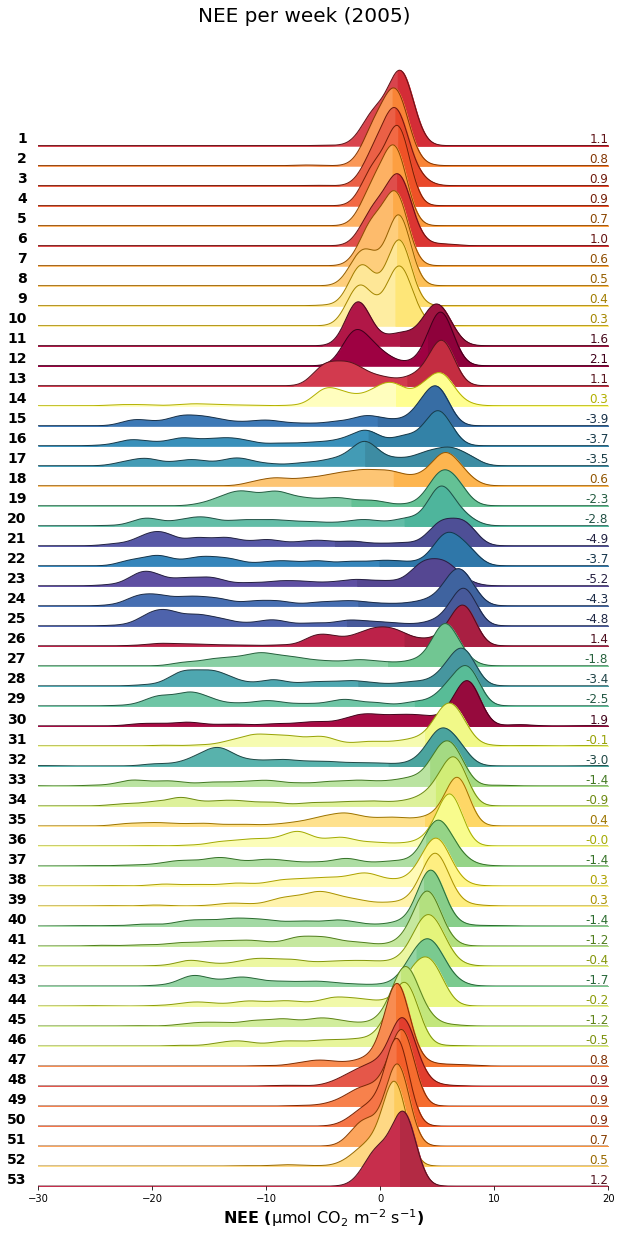

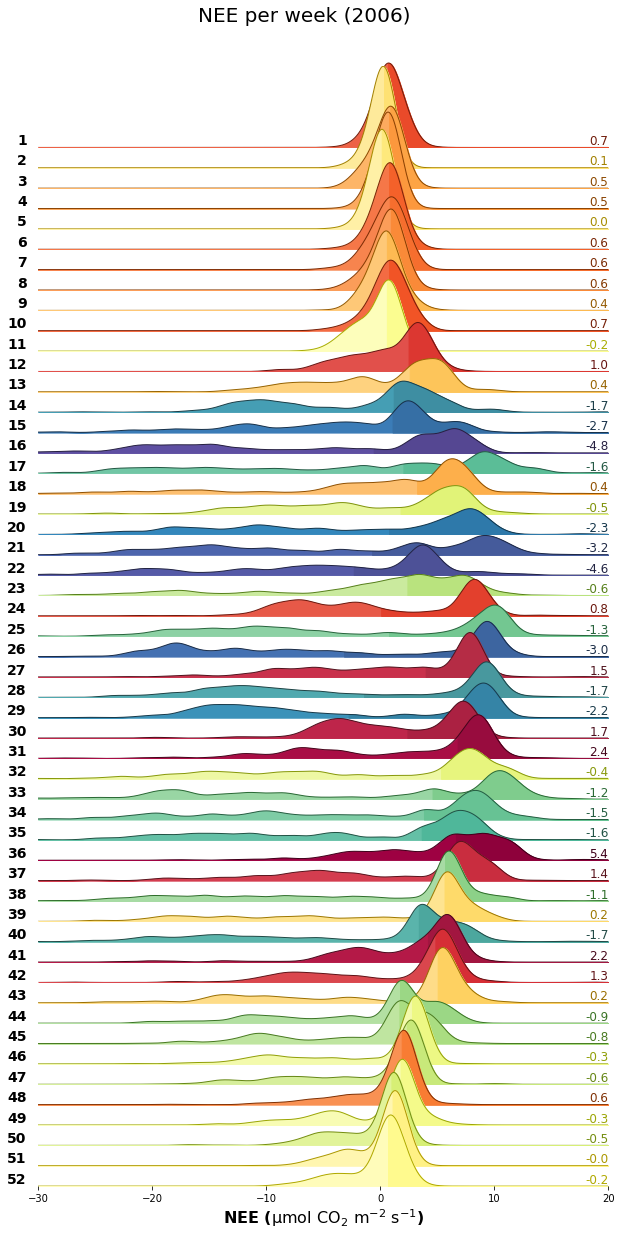

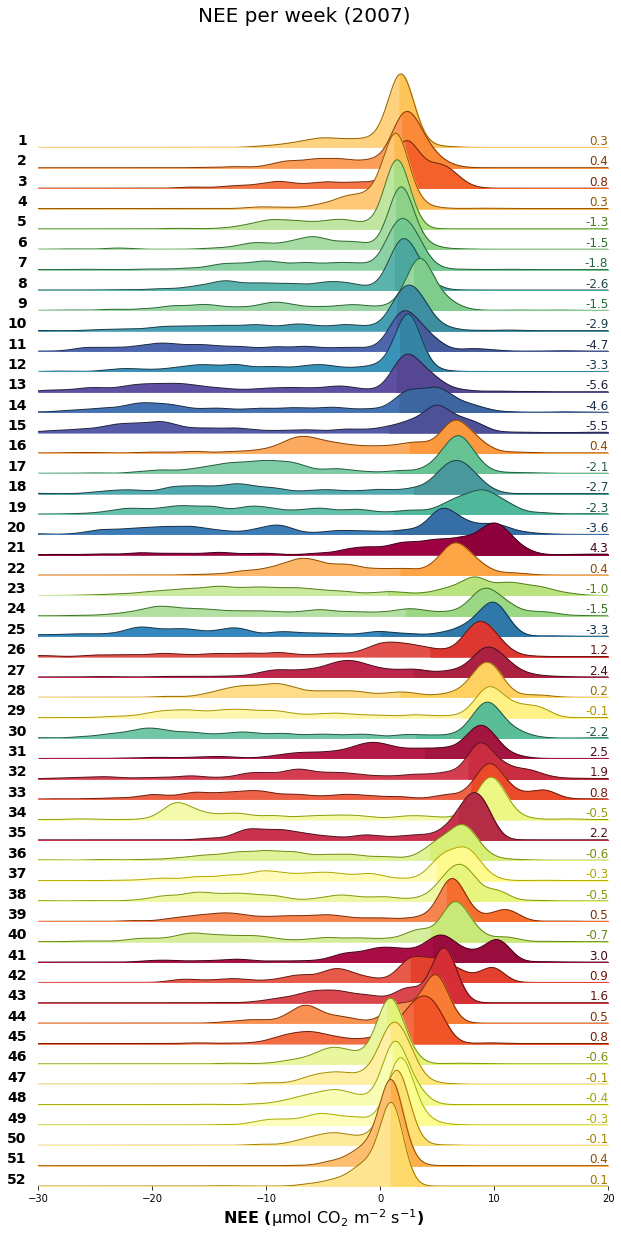

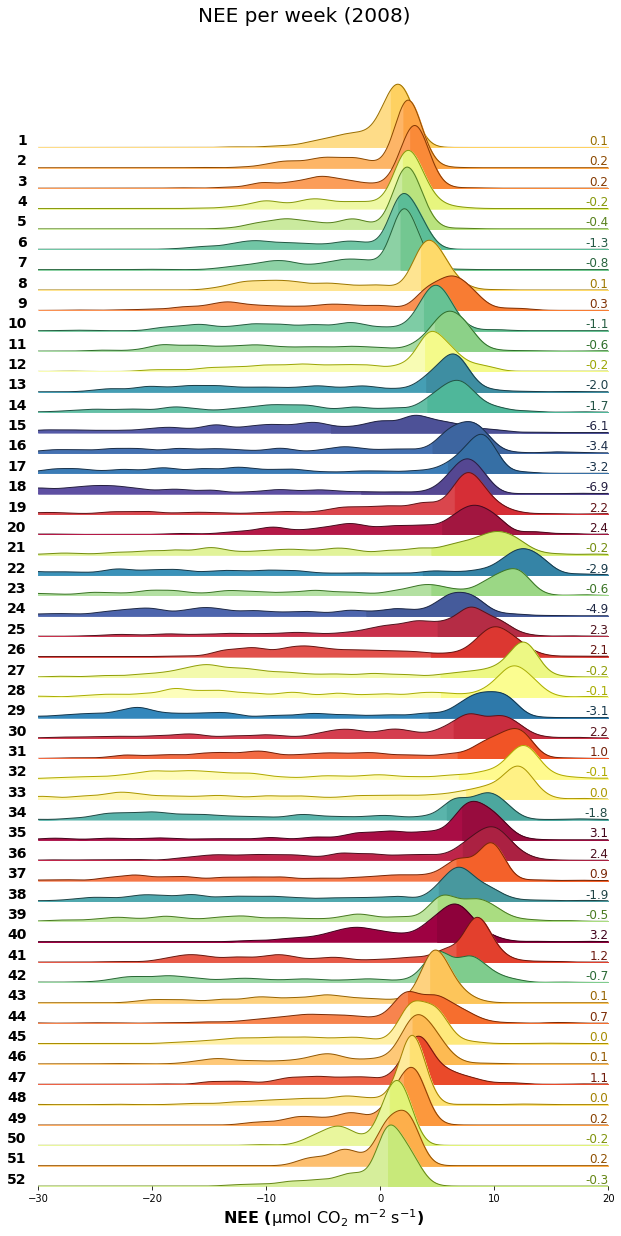

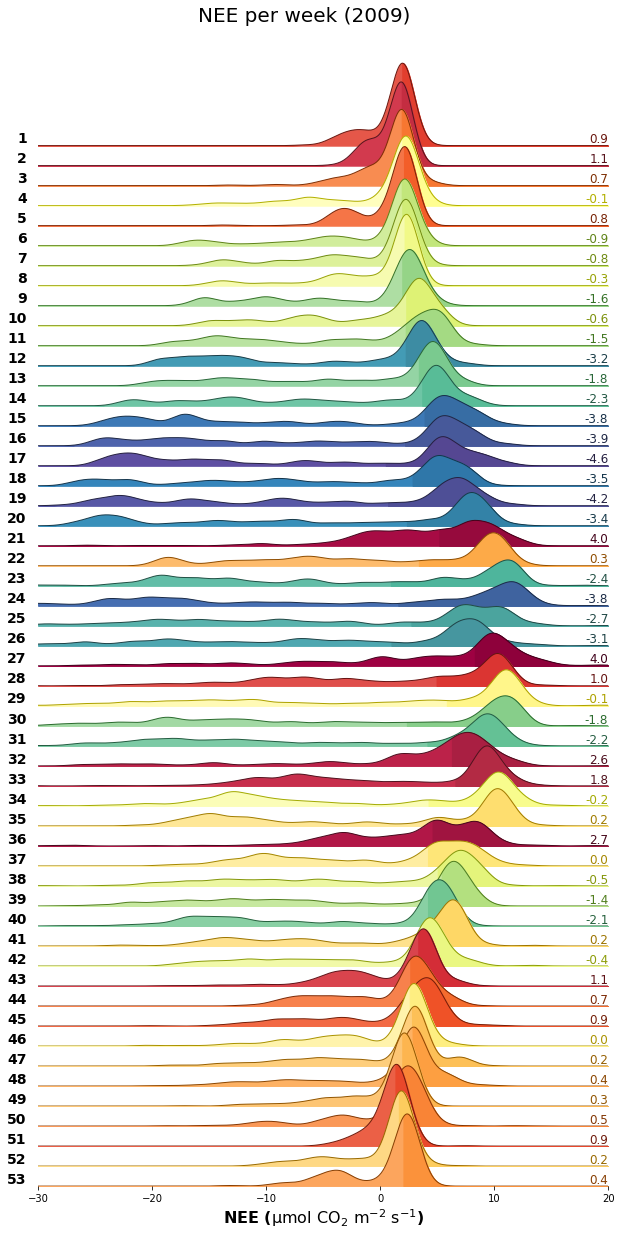

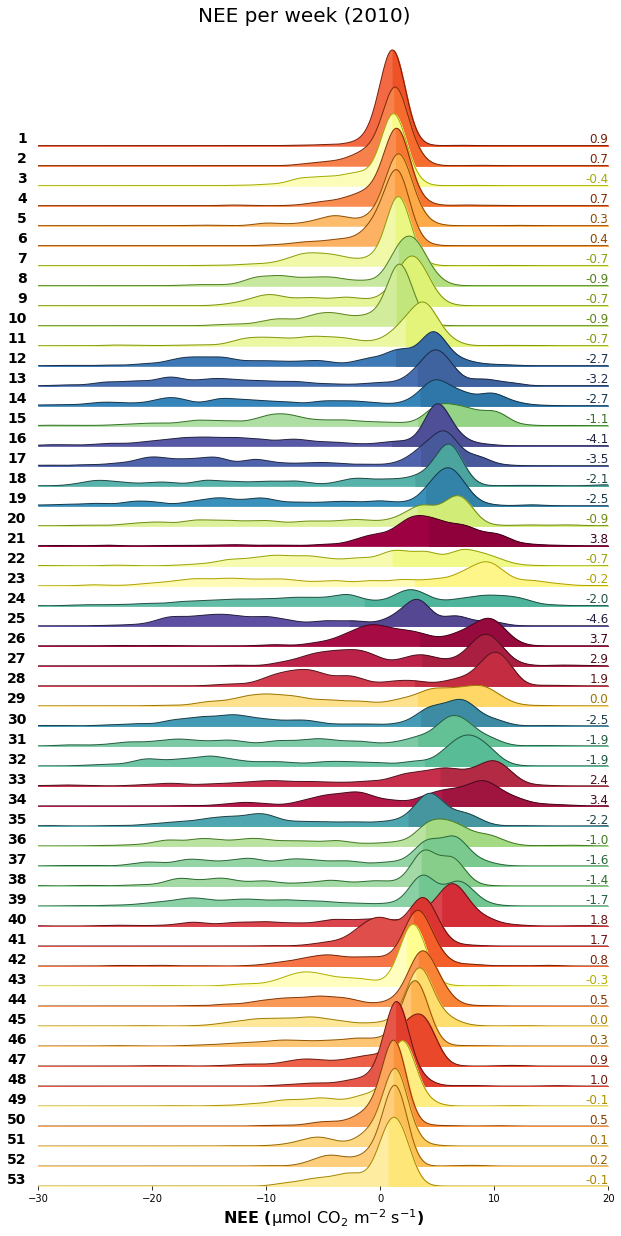

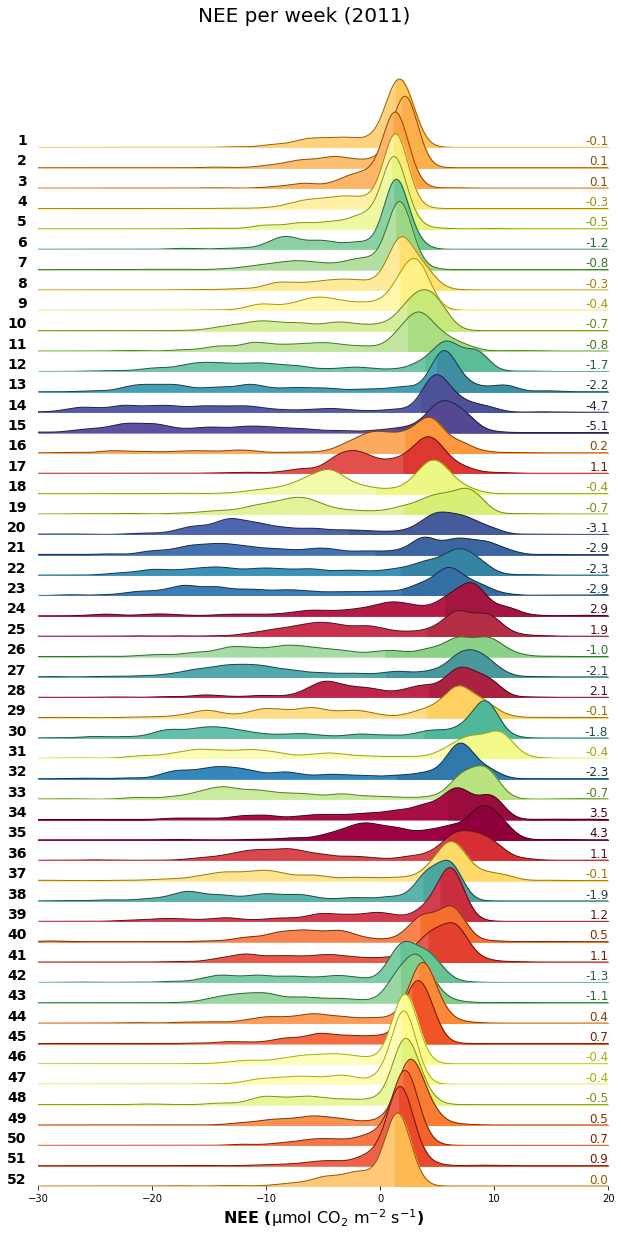

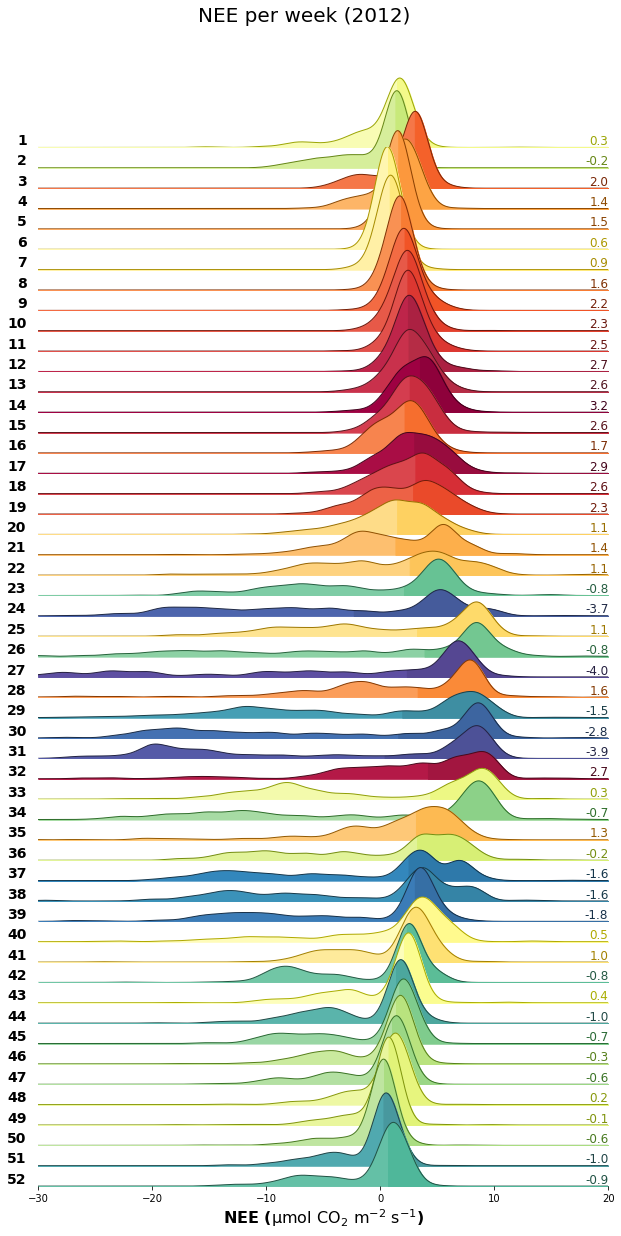

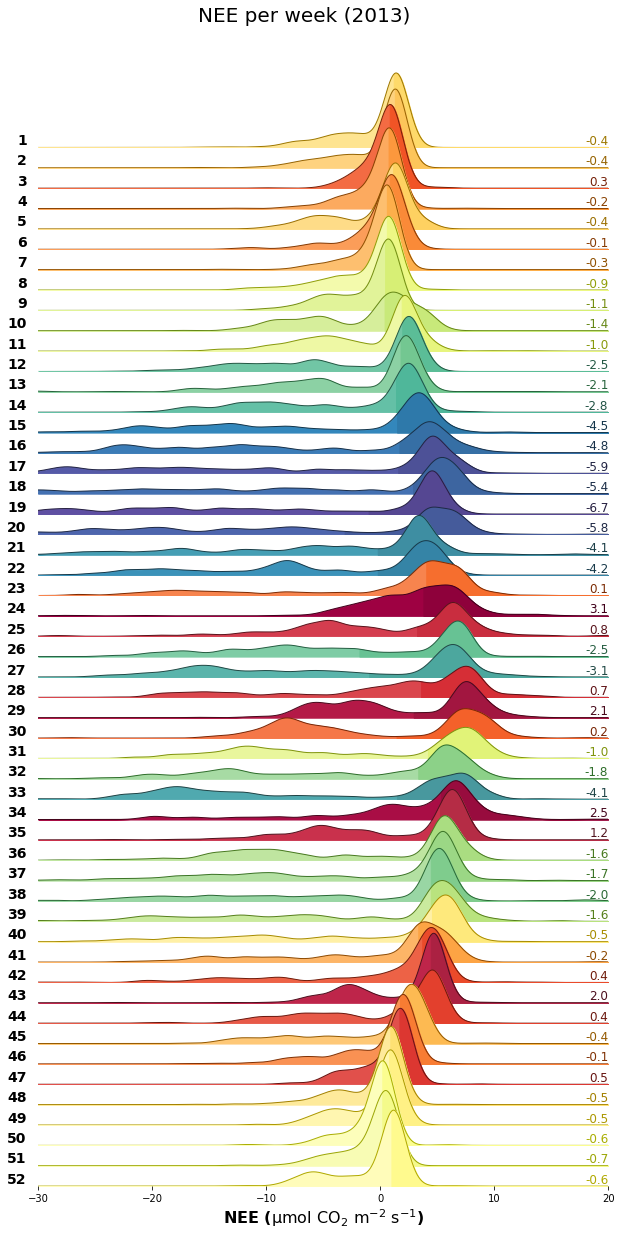

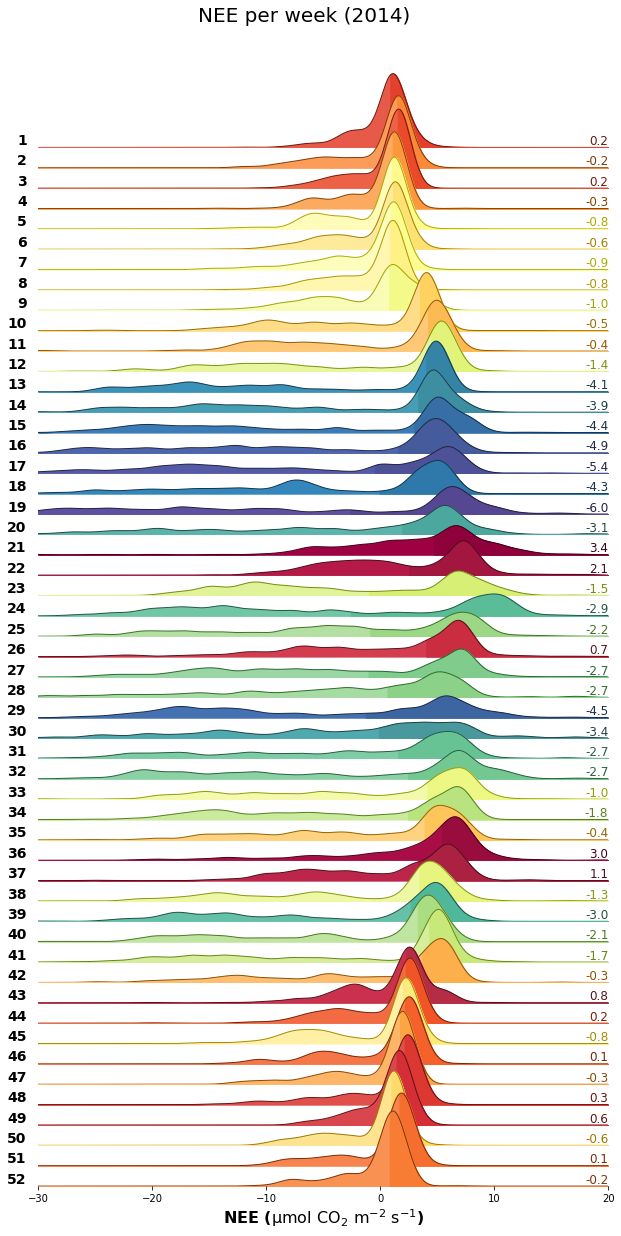

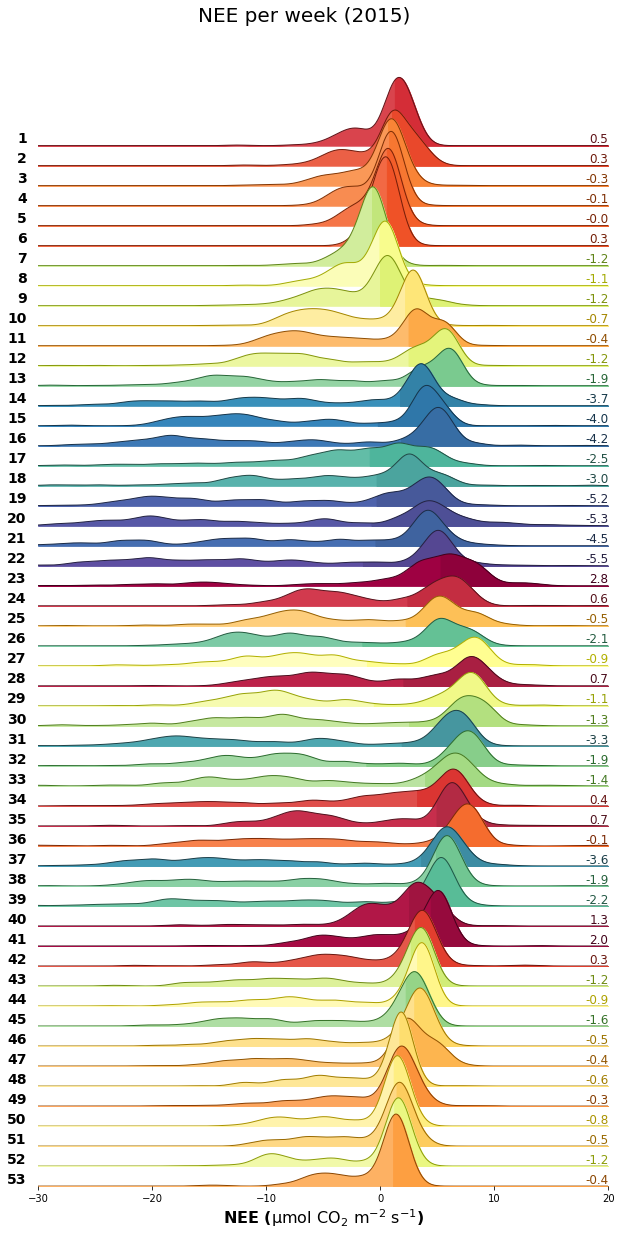

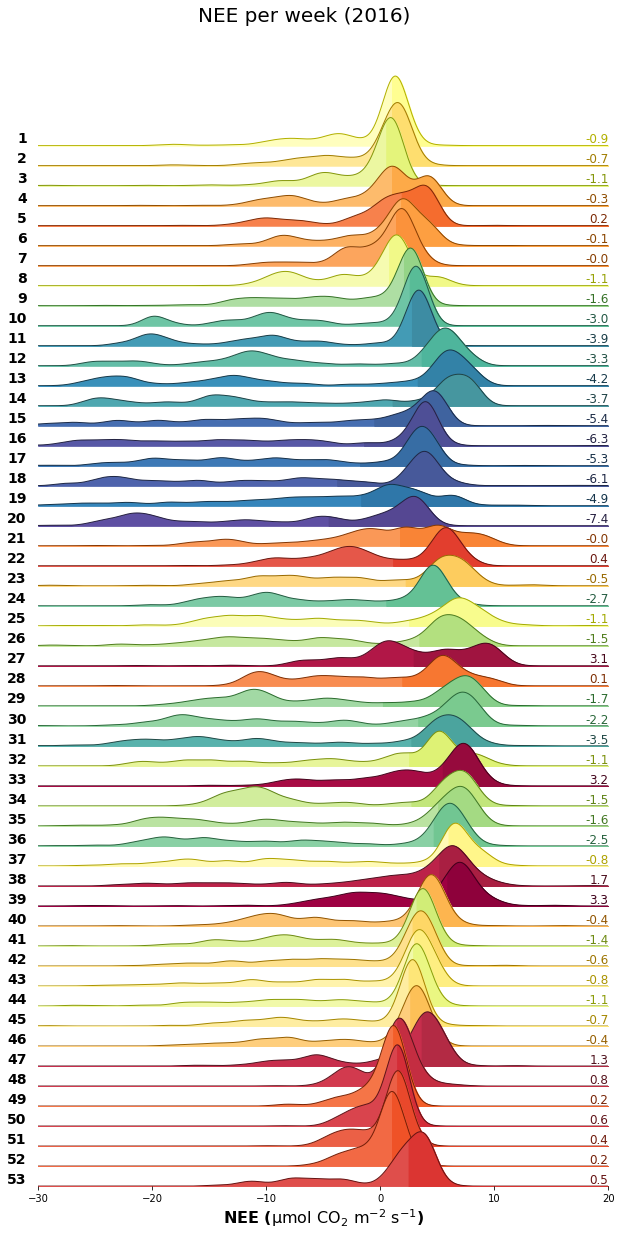

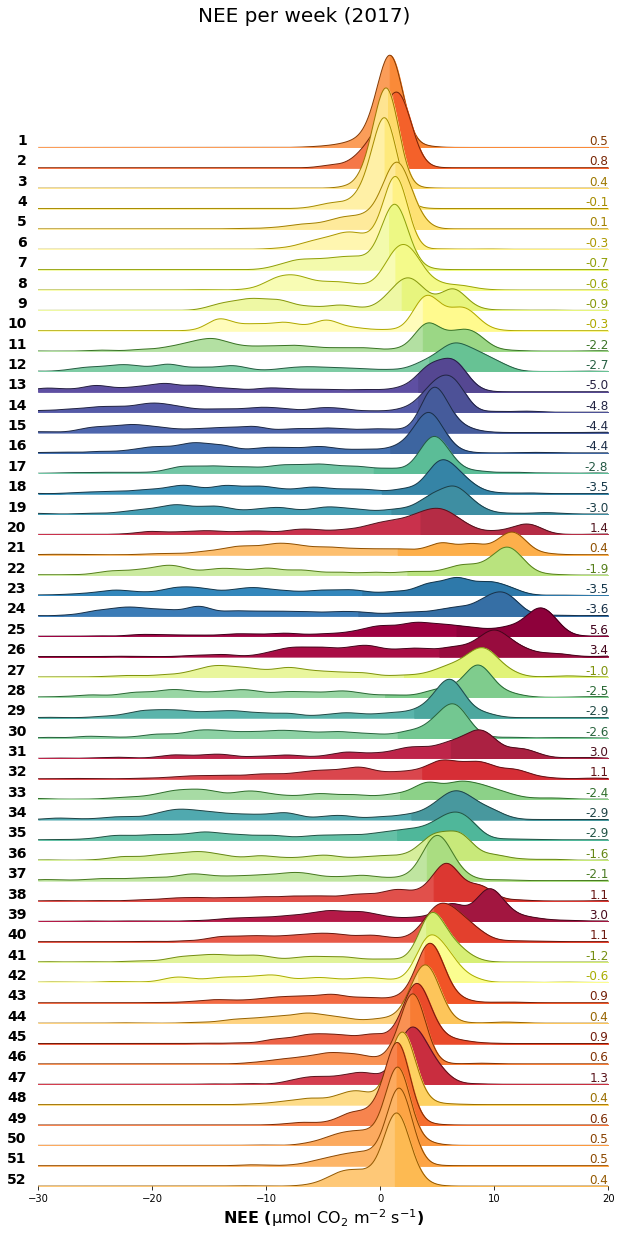

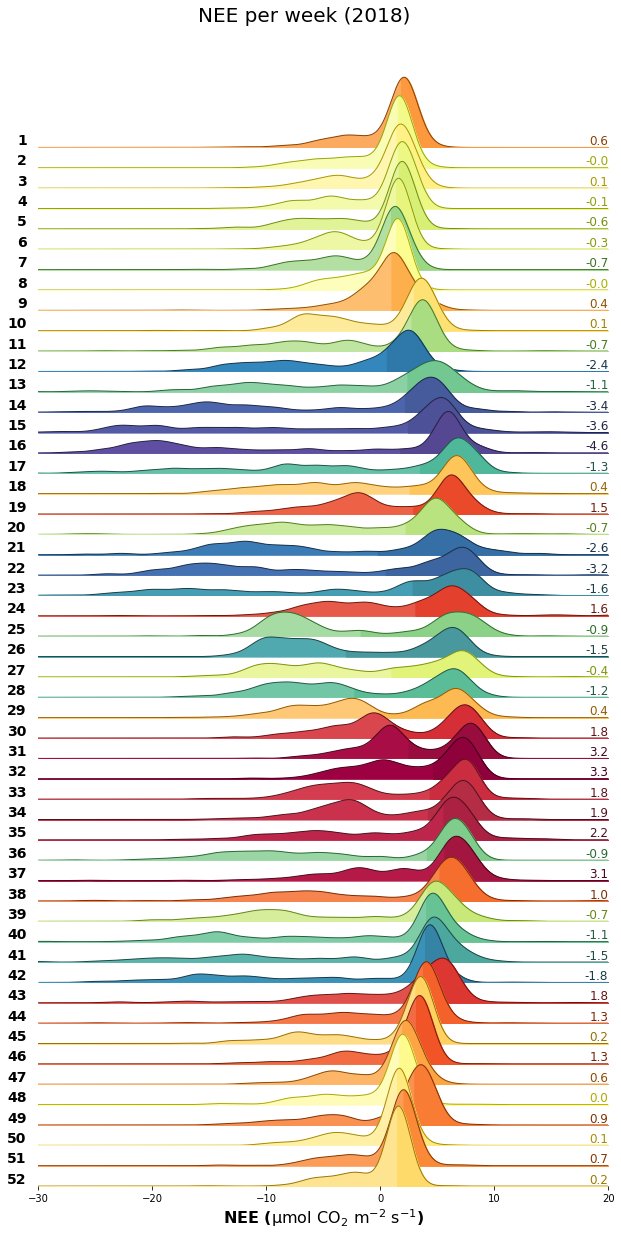

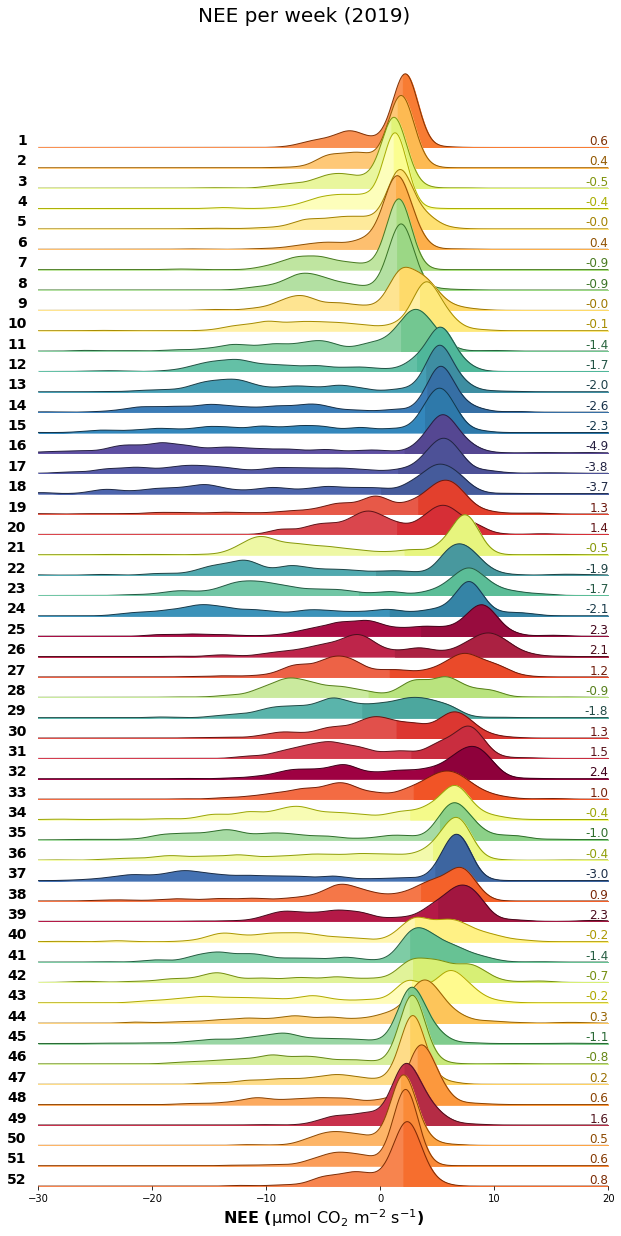

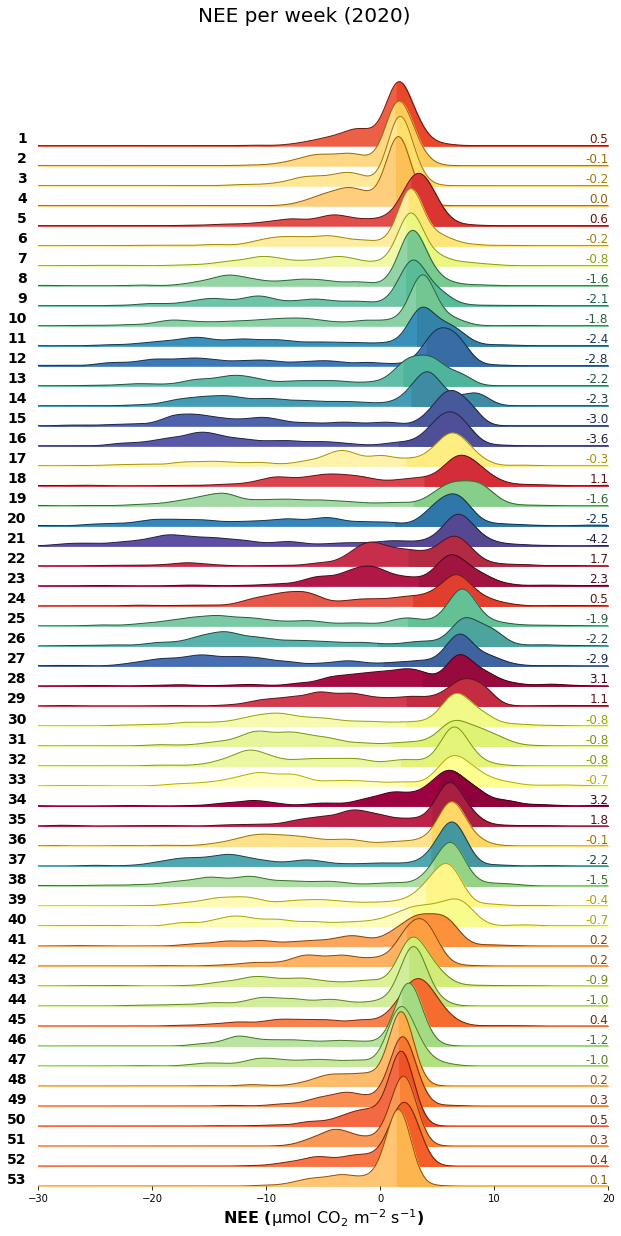

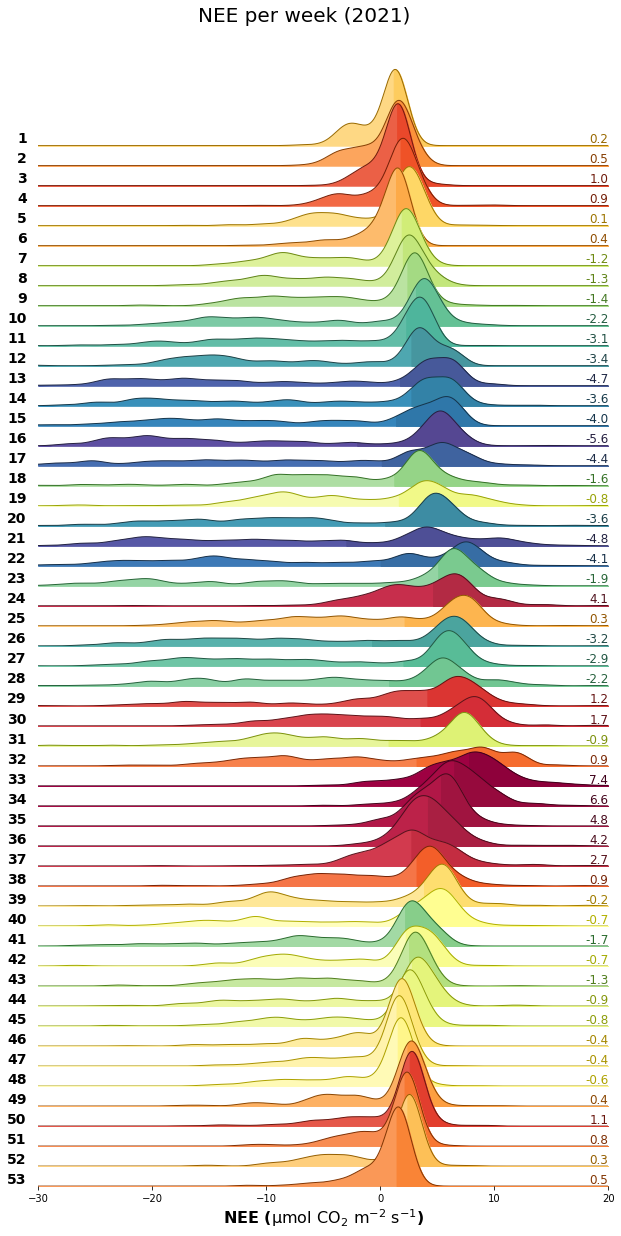

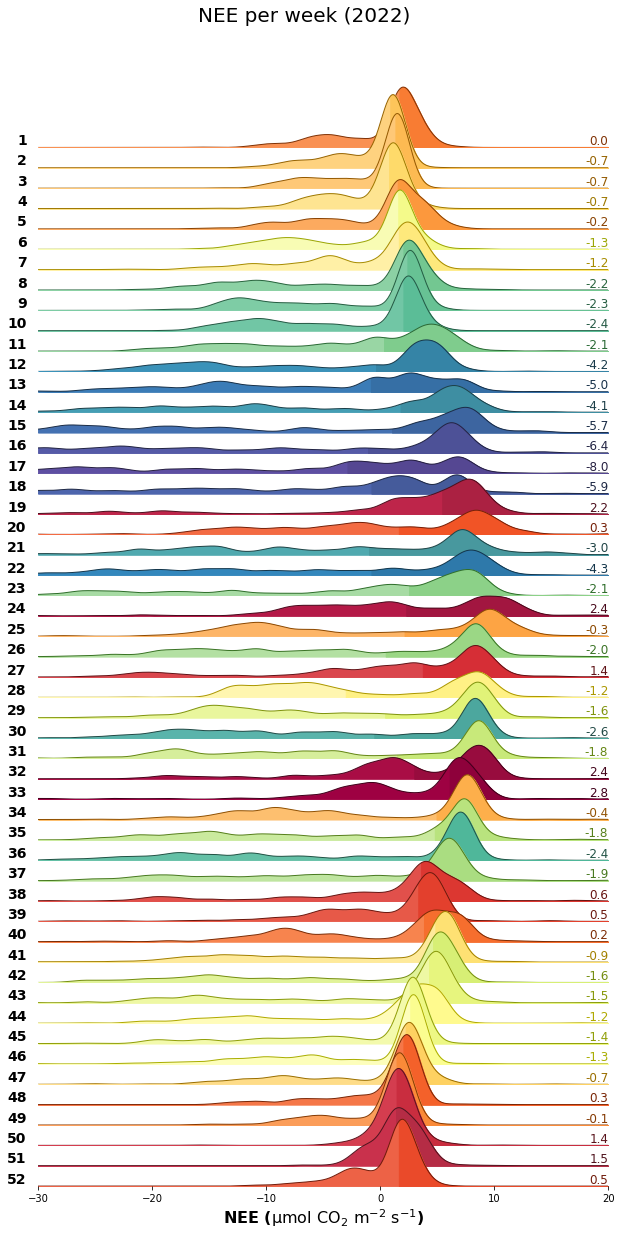

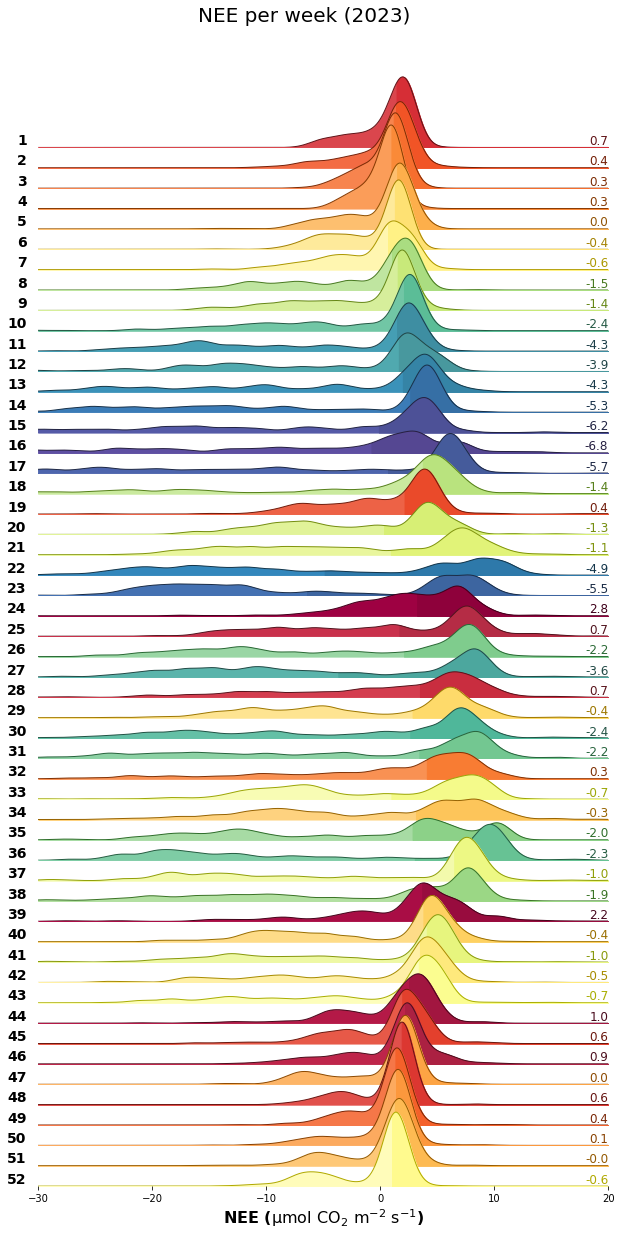

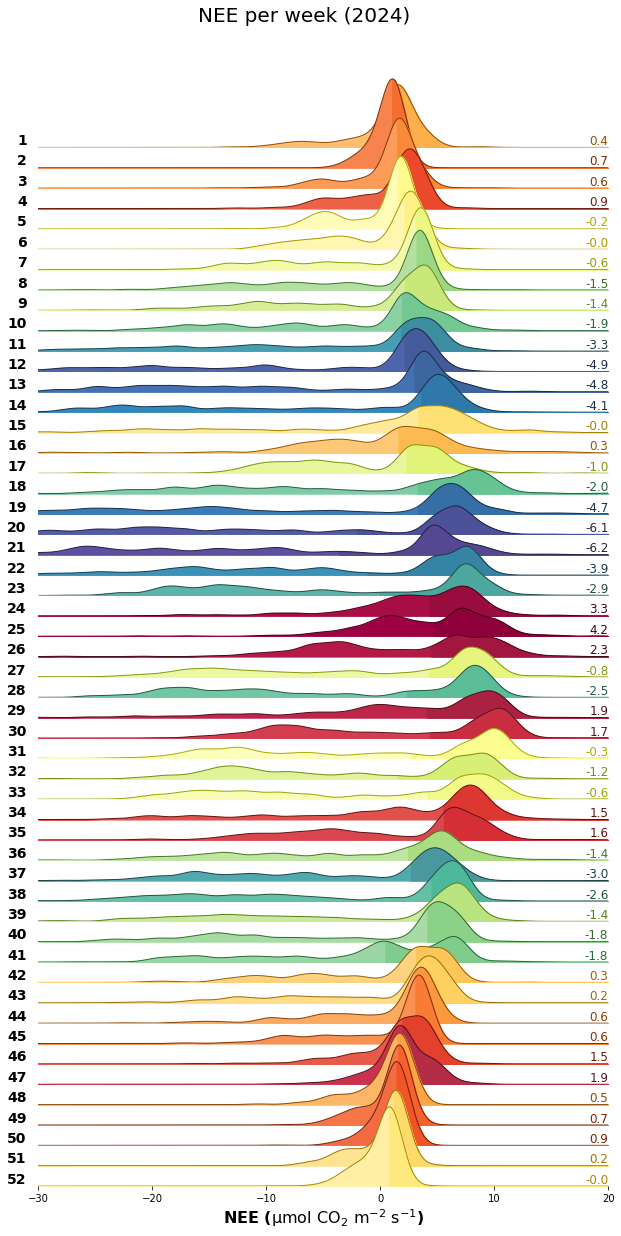

In [28]:
uniq_years = series.index.year.unique()
for uy in uniq_years:
    series_yr = series.loc[series.index.year == uy].copy()
    rp = RidgePlotTS(series=series_yr)
    rp.per_week(xlim=[-30, 20], ylim=[0, 0.35], hspace=-0.8, xlabel=xlabel,
                 fig_width=9, fig_height=18, shade_percentile=0.5, show_mean_line=False,
                 fig_title=f"{var} per week ({uy})", fig_dpi=72)

# **End of notebook**

In [9]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-03-03 15:26:38
